# Evaluating the parity-flip reconstruction on a measured trace

A measured trace has **no truth**: nobody knows when the quasiparticles actually
tunnelled, so `score_flips` cannot be run on it and the reconstruction's
efficiency and timing accuracy on that dataset are unknown. Everything the
pipeline reports about a real trace (`contrast`, `decoded_fidelity`,
`degenerate`) measures *self-consistency with the fitted model*, not
correctness.

This notebook closes that gap by **surrogate replay**, then uses the same
machinery to answer three detector questions and to compare the two HMM
decoding rules.

1. **Fit the two branches by EM** — where the whole pipeline starts
2. Characterise the trace and benchmark it (§12c of `docs/reconstruction.md`)
3. Flip efficiency vs background tunnelling rate
4. Burst detection efficiency vs quasiparticle number
5. Burst multiplicity bias
6. **Viterbi vs forward-backward** — the same plots under the other decoder

Everything here is at a **constant offset charge**, which is the operating point
these diagnostics target (§12d).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Run from anywhere in the repo: prefer this checkout's src over any install.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "qpd").is_dir())
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "checks"))

from qpd.reconstruction import (                      # noqa: E402
    benchmark_reconstruction, characterize_trace, detect_bursts, fit_two_blobs,
    match_bursts, plot_burst_efficiency, plot_burst_multiplicity,
    plot_efficiency_vs_rate, plot_iq_plane, plot_trace_with_flips, score_flips,
    sweep_burst_size, sweep_rate,
)

SR = 1e5          # sampling rate [Hz]
DECODERS = ("viterbi", "posterior")
print("qpd loaded from", ROOT / "src")

qpd loaded from /Users/lanqingyuan/Documents/GitHub/qpd/.claude/worktrees/admiring-chandrasekhar-a68529/src


## 1. The measured trace

**Replace this cell with your own data.** All the notebook needs is a complex
`iq` array and its sample rate; `as_complex_trace` also accepts real `(n, 2)`
or `(2, n)` I/Q.

Here we simulate one so that the answers can be checked against a truth the
benchmark never sees — that check is the whole point of §4.

In [2]:
from reconstruction_scenarios import build_static_scenario   # noqa: E402

scenario = build_static_scenario(n_g=0.0, duration=5.0, tunnel_rate_hz=10.0)
truth = scenario.simulate(seed=1)          # <- truth kept aside, never shown to the benchmark
iq = truth.iq

print(f"{iq.size} samples, {iq.size / SR:.1f} s at {SR/1e3:.0f} kSa/s")
print(f"(withheld truth: {truth.flip_times.size} flips "
      f"= {truth.flip_times.size / 5:.2f} Hz per state)")

500000 samples, 5.0 s at 100 kSa/s
(withheld truth: 38 flips = 7.60 Hz per state)


## 2. Where it starts: the EM fit of the two branches

Nothing can be decoded until the two branches are located, and on measured data
they have to be found **blind** — no device parameters, no noise level, no idea
which way the parity axis points.

Two facts collapse this to one dimension. The drive is parked far off
resonance, so the parity-dependent part of $S_{21}$ is one *fixed* complex
vector scaled by a real factor: the two branch means differ along a single
line, which cannot rotate. And the noise is isotropic. So the cloud's principal
axis **is** the discrimination axis, and projecting onto it throws nothing
away.

On that axis the data is a two-component Gaussian mixture with a shared width.
`fit_two_blobs` recovers it by expectation-maximisation, initialised by
splitting the projection at its median — deliberately, because a k-means-style
split at the extremes biases the centres outward when the blobs overlap.

In [3]:
blobs = fit_two_blobs(iq)

print(f"discrimination axis   {np.angle(blobs.direction, deg=True):+7.2f} deg in the I/Q plane")
print(f"branch centres        mu_A = {blobs.mu_a:+.4e}")
print(f"                      mu_B = {blobs.mu_b:+.4e}")
print(f"separation            {blobs.separation:.4e}")
print(f"noise sigma           {blobs.sigma:.4e}")
print(f"contrast              {blobs.contrast:7.3f}   <- separation / sigma, the number that decides everything")
print(f"occupancy of A        {blobs.weight_a:7.3f}   <- fraction of TIME in A, not 1/2 exactly:")
print(f"                                 this trace holds ~{truth.flip_times.size} dwells, so the time")
print(f"                                 split scatters by ~{1/np.sqrt(truth.flip_times.size/2):.2f}")
print(f"EM iterations         {blobs.n_iter:7d}")
print()
print("cross-check: sigma from the minor axis (noise only, independent of the mixture fit)")
print(f"  minor-axis sigma    {blobs.diagnostics['sigma_minor_axis']:.4e}"
      f"   ratio {blobs.diagnostics['sigma_ratio_fit_over_minor']:.4f}")

discrimination axis   +125.00 deg in the I/Q plane
branch centres        mu_A = +4.7426e-04
                      mu_B = -2.8491e-04
separation            7.5917e-04
noise sigma           1.9956e-04
contrast                3.804   <- separation / sigma, the number that decides everything
occupancy of A          0.375   <- fraction of TIME in A, not 1/2 exactly:
                                 this trace holds ~38 dwells, so the time
                                 split scatters by ~0.23
EM iterations              22

cross-check: sigma from the minor axis (noise only, independent of the mixture fit)
  minor-axis sigma    1.9984e-04   ratio 0.9986


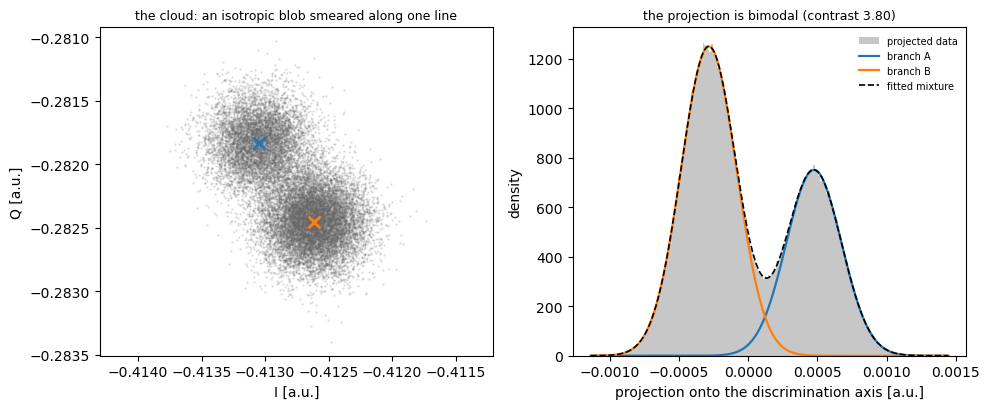

In [4]:
x = blobs.project(iq)
fig, (axl, axr) = plt.subplots(1, 2, figsize=(10.0, 4.2))

plot_iq_plane(iq, model=blobs, ax=axl)
axl.set_title("the cloud: an isotropic blob smeared along one line", fontsize=9)

axr.hist(x, bins=220, density=True, color="0.78", label="projected data")
g = np.linspace(x.min(), x.max(), 600)


def gauss(mu):
    return np.exp(-0.5 * ((g - mu) / blobs.sigma) ** 2) / (
        blobs.sigma * np.sqrt(2 * np.pi))


wa = blobs.weight_a
axr.plot(g, wa * gauss(blobs.mu_a), lw=1.6, color="tab:blue", label="branch A")
axr.plot(g, (1 - wa) * gauss(blobs.mu_b), lw=1.6, color="tab:orange",
         label="branch B")
axr.plot(g, wa * gauss(blobs.mu_a) + (1 - wa) * gauss(blobs.mu_b), "k--",
         lw=1.2, label="fitted mixture")
axr.set_xlabel("projection onto the discrimination axis [a.u.]")
axr.set_ylabel("density")
axr.set_title(f"the projection is bimodal (contrast {blobs.contrast:.2f})",
              fontsize=9)
axr.legend(fontsize=7, frameon=False)
fig.tight_layout()
plt.show()

### The trap: EM always "succeeds"

The fit above looks convincing, but a fitted separation is **not** evidence
that the bias point carries any parity information. Fitting two components to
*one* blob does not fail — EM splits a single Gaussian into a spurious pair and
reports a perfectly healthy-looking contrast near 1.

Worth seeing rather than taking on trust, because it is the failure mode behind
every silent-garbage result in these notes:

In [5]:
rng = np.random.default_rng(0)
pure_noise = (rng.normal(0, blobs.sigma, iq.size)
              + 1j * rng.normal(0, blobs.sigma, iq.size))
spurious = fit_two_blobs(pure_noise)

print("input: isotropic Gaussian noise, no parity signal whatsoever")
print(f"  fitted separation   {spurious.separation:.4e}")
print(f"  fitted contrast     {spurious.contrast:.3f}   <- NOT zero")
print()
print(f"real trace, for comparison: contrast {blobs.contrast:.3f}")

input: isotropic Gaussian noise, no parity signal whatsoever
  fitted separation   1.6541e-04
  fitted contrast     0.909   <- NOT zero

real trace, for comparison: contrast 3.804


So contrast alone cannot separate a usable bias from a parity-blind one — a
spurious split scores ~0.9 and a marginal-but-real point scores ~0.96. (The
likelihood gain of two blobs over one was tried as a discriminator and is no
help either: on the reference device it is ≈0 for the usable $n_g = 0.22$ and
the blind $n_g = 0.24$ alike.) That is
why the pipeline gates on **two** statistics that fail on different axes: the
per-sample contrast, and the contrast integrated over one dwell
(`contrast * sqrt(dwell)`). `degenerate` is raised only when *both* fail, which
is what makes it trustworthy in each direction (§13b).

Everything from here on is built on this fit: the HMM uses `mu_A`, `mu_B` and
`sigma` as its emission model, and the surrogate replay in §4 pushes a fresh
telegraph back through exactly these numbers.

## 3. Characterise it, and decode

`characterize_trace` runs the whole pipeline: the EM fit of §2, then the
two-state HMM decode that turns it into events, with the flip rate re-estimated
from the data. It returns the fitted forward model — the same discrimination
axis, noise σ and branch separation as above, plus the decoded rate.

**That model is the measurement's fidelity**, and it is what gets replayed.

In [6]:
fid = characterize_trace(iq, SR)
print(fid.describe())

mode                 static
samples              500000  (5 s at 1e+05 Hz)
noise sigma          0.0001996
contrast (median)    3.804
contrast (max)       3.804
decoded rate         7.6 Hz per state
flips found          38
single-sample fid.   0.9714
decoded fidelity     1.0000


### What it actually found

The point of this view is to put the *input* and the *output* on one time axis:
the raw I and Q that went in, and the tunnelling times that came out. At a fixed
bias the raw trace is already informative — `smooth_hz` low-passes it so the
telegraph is plain to the eye — and the flips should land exactly on the edges.

Green = truth, red dashed = reconstructed. **Drop `truth_times` on measured
data**; there is no truth to pass.

/Users/lanqingyuan/Documents/GitHub/qpd/.claude/worktrees/admiring-chandrasekhar-a68529/src/qpd/reconstruction/plotting.py:270: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


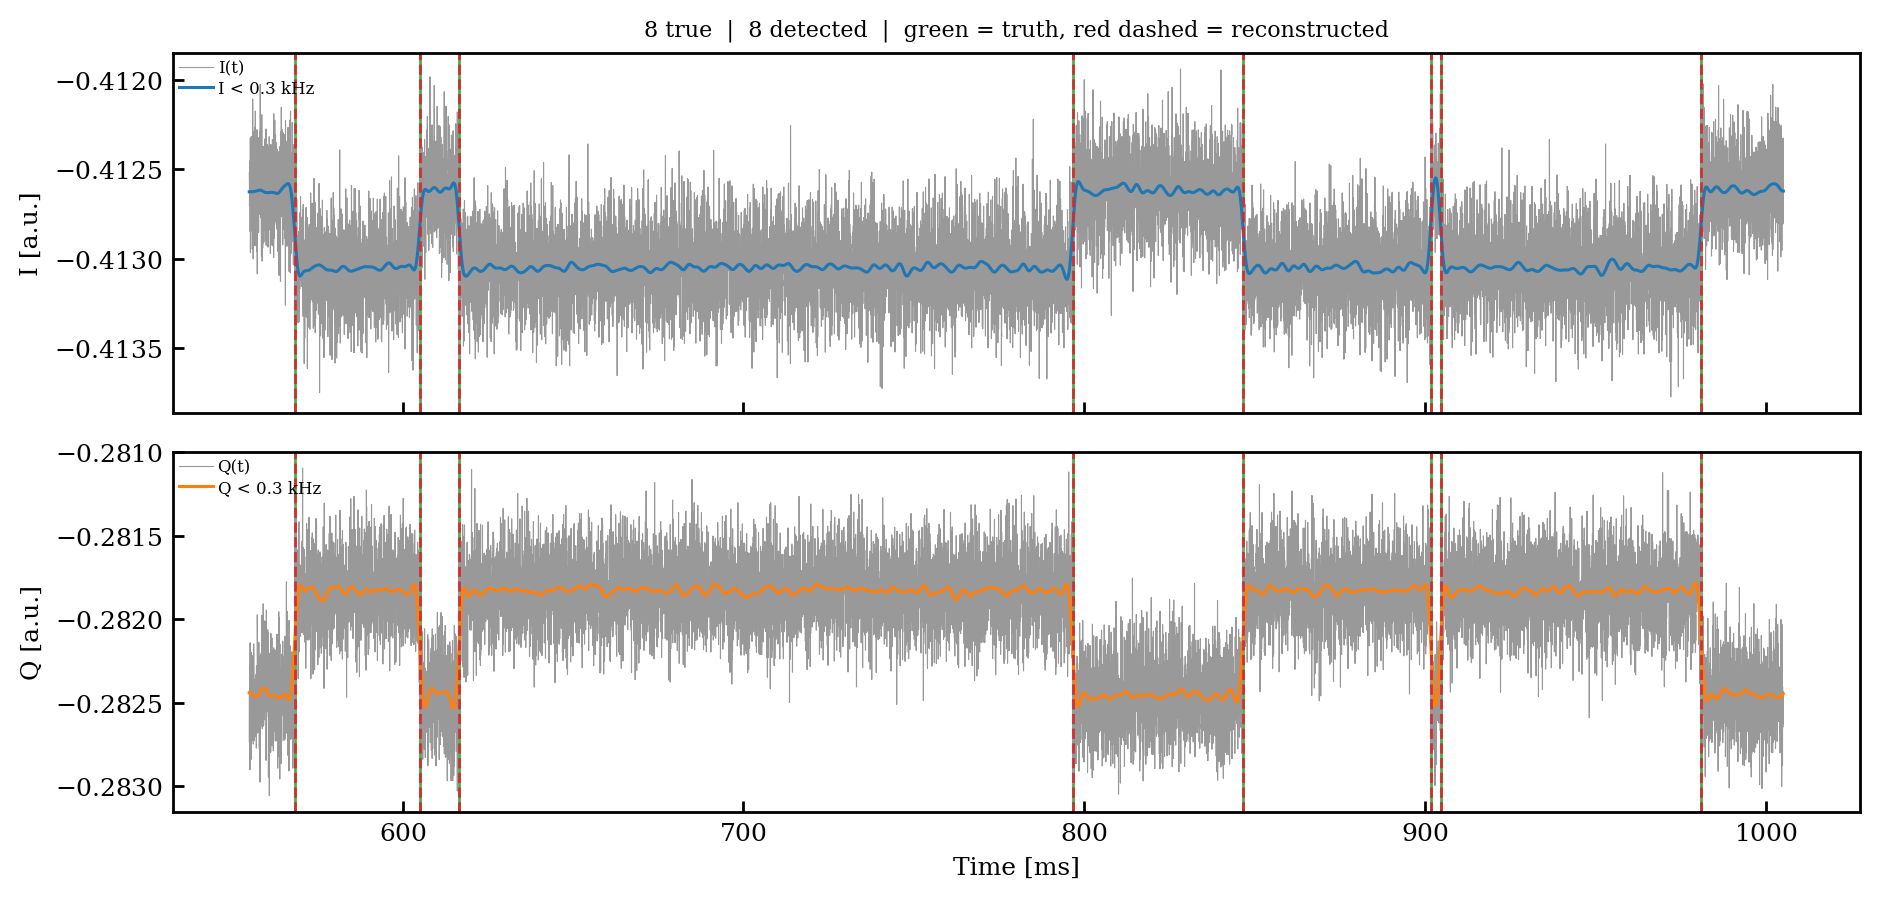

window 0.555-1.005 s: 8 true flips, 8 reconstructed


In [7]:
# Zoom somewhere that actually contains a few flips: a whole 5 s trace drawn at
# 100 kSa/s is a solid band.
start = fid.result.flip_times[2] - 0.05
window = (start, start + 0.45)

fig, axes = plot_trace_with_flips(
    iq, SR, fid.result.flip_times,
    truth_times=truth.flip_times,
    window=window, smooth_hz=300.0,
)
plt.show()

n_in = np.count_nonzero((truth.flip_times >= window[0])
                        & (truth.flip_times < window[1]))
n_rec = np.count_nonzero((fid.result.flip_times >= window[0])
                         & (fid.result.flip_times < window[1]))
print(f"window {window[0]:.3f}-{window[1]:.3f} s: {n_in} true flips, {n_rec} reconstructed")

And the companion view — the same trace in the I/Q plane, now coloured by the
branch the HMM assigned to each sample, with the EM centres from §2 marked. This
is the picture that shows *why* the problem reduces to one dimension, and on
measured data it is the strongest evidence available that the fit is real:
either there are two separated blobs or there are not.

/Users/lanqingyuan/Documents/GitHub/qpd/.claude/worktrees/admiring-chandrasekhar-a68529/src/qpd/reconstruction/plotting.py:319: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


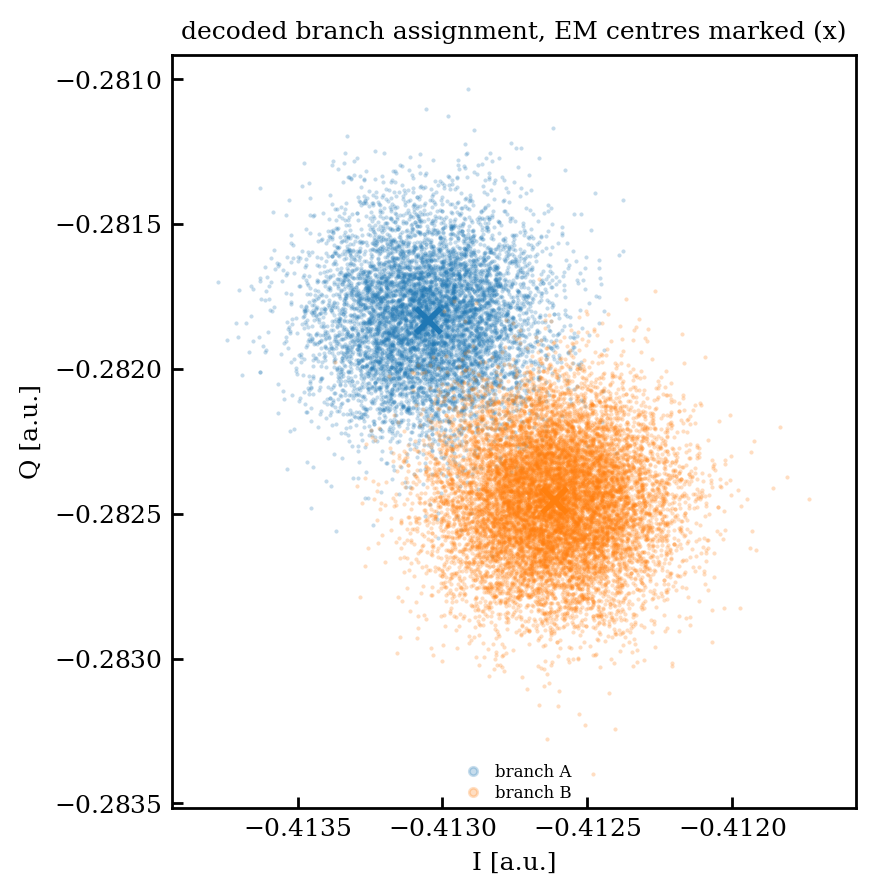

In [8]:
fig, ax = plot_iq_plane(iq, branch=fid.result.branch, model=blobs,
                        figsize=(4.6, 4.4))
ax.set_title("decoded branch assignment, EM centres marked (x)", fontsize=9)
plt.show()

## 4. Benchmark: efficiency and accuracy at this fidelity

A fresh telegraph is pushed back through the fitted model with fresh noise,
producing traces the decoder cannot distinguish from the real one but whose
flip times are known exactly. Reconstructing a batch of those blind gives
efficiency, purity and timing with error bars.

In [9]:
report = benchmark_reconstruction(fidelity=fid, n_trials=12)
print(report.summary())

Measured trace
--------------
mode                 static
samples              500000  (5 s at 1e+05 Hz)
noise sigma          0.0001996
contrast (median)    3.804
contrast (max)       3.804
decoded rate         7.6 Hz per state
flips found          38
single-sample fid.   0.9714
decoded fidelity     1.0000

Reconstruction performance at this fidelity (12 surrogate trials)
------------------------------------------------------------------------
efficiency (recall)  1.000 +/- 0.000
purity (precision)   1.000 +/- 0.000
hard F1              1.000 +/- 0.000
soft F1 (timed)      1.000 +/- 0.000
timing bias          -0.3 +/- 0.7 us
timing rms           4.1 +/- 1.5 us
match tolerance      500 us
closure (sim/meas)   1.000

Implied rate on the measured trace: 7.6 Hz per state (decoder reported 7.6 Hz)

Per-trial
   truth   pred  match    effic  purity  hardF1  softF1   bias/us   rms/us
      30     30     30    1.000   1.000   1.000   0.999      -0.6      8.3
      37     37     37    1.000   1

### Does it actually predict?

Now we may look at the truth the benchmark never saw.

In [10]:
actual = score_flips(truth.flip_times, fid.result.flip_times)
rows = [
    ("efficiency", f"{report.efficiency[0]:.3f} +/- {report.efficiency[1]:.3f}",
     f"{actual.efficiency:.3f}"),
    ("purity", f"{report.purity[0]:.3f} +/- {report.purity[1]:.3f}",
     f"{actual.purity:.3f}"),
    ("rate [Hz]", f"{report.corrected_rate_hz:.2f}",
     f"{truth.flip_times.size / 5:.2f}"),
]
print(f"{'':<12} {'benchmark said':>22} {'withheld truth':>16}")
for name, pred, act in rows:
    print(f"{name:<12} {pred:>22} {act:>16}")

                     benchmark said   withheld truth
efficiency          1.000 +/- 0.000            1.000
purity              1.000 +/- 0.000            1.000
rate [Hz]                      7.60             7.60


## 5. Flip efficiency vs background tunnelling rate

The background is Poisson, so the rate alone sets how often two tunnels land
closer than the decoder can resolve. An unresolved pair is **invisible, not
merely mistimed** — two toggles return the parity to where it started — so
crowding removes flips silently and costs *recall* long before *precision*.

  rate/Hz   effic  purity      F1
        1   1.000   1.000   1.000
        3   1.000   1.000   1.000
       10   1.000   1.000   1.000
       30   1.000   1.000   1.000
      100   0.993   0.999   0.996
      300   0.988   0.999   0.993
     1000   0.972   0.998   0.985
     3000   0.939   0.993   0.965
    1e+04   0.863   0.983   0.919
    3e+04   0.700   0.952   0.807


/Users/lanqingyuan/Documents/GitHub/qpd/.claude/worktrees/admiring-chandrasekhar-a68529/src/qpd/reconstruction/benchmark_plots.py:138: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


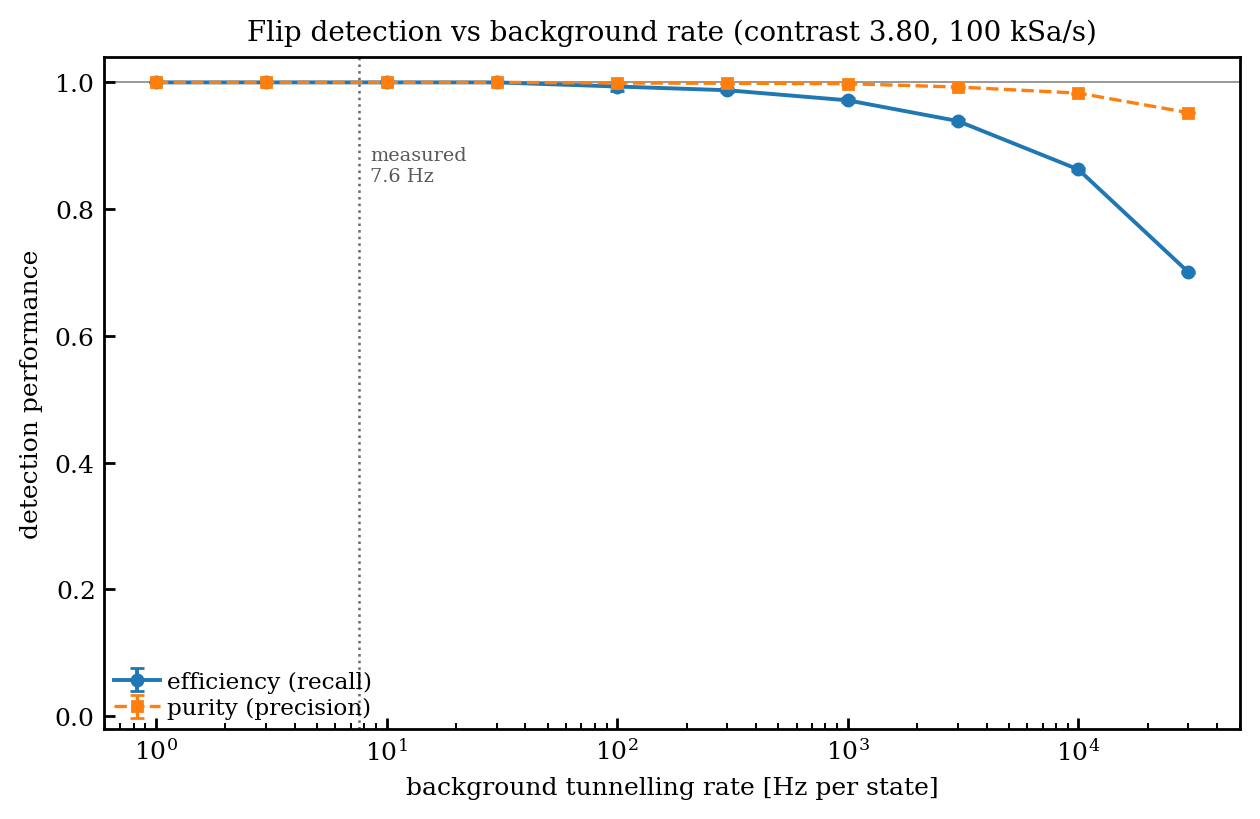

In [11]:
RATES = [1, 3, 10, 30, 100, 300, 1e3, 3e3, 1e4, 3e4]
sweeps = {d: sweep_rate(characterize_trace(iq, SR, decoder=d), RATES, n_trials=4)
          for d in DECODERS}

fig, ax = plot_efficiency_vs_rate(sweeps["viterbi"])
print(f"{'rate/Hz':>9} {'effic':>7} {'purity':>7} {'F1':>7}")
for r, rep in zip(RATES, sweeps["viterbi"]):
    print(f"{r:9.4g} {rep.efficiency[0]:7.3f} {rep.purity[0]:7.3f} "
          f"{rep.hard_f1[0]:7.3f}")
plt.show()

## 6. The same plot under forward-backward decoding

Both rules use the **same** fitted emissions and the **same** flip prior — the
rate is estimated from the posterior either way — so this isolates the decoding
step and nothing else.

- **Viterbi** returns the single most likely branch *sequence*. The transition
  prior is paid once per flip, so a brief dip in the evidence does not create a
  flip *pair* unless it earns its keep globally. Conservative.
- **Forward-backward** returns the per-sample marginal, thresholded at ½. It
  maximises the expected number of correctly labelled *samples* — a different
  objective — and nothing couples neighbouring decisions once the marginals are
  formed, so it follows short excursions Viterbi smooths over.

Expect the posterior rule to find *more* real flips and to invent *more* too.

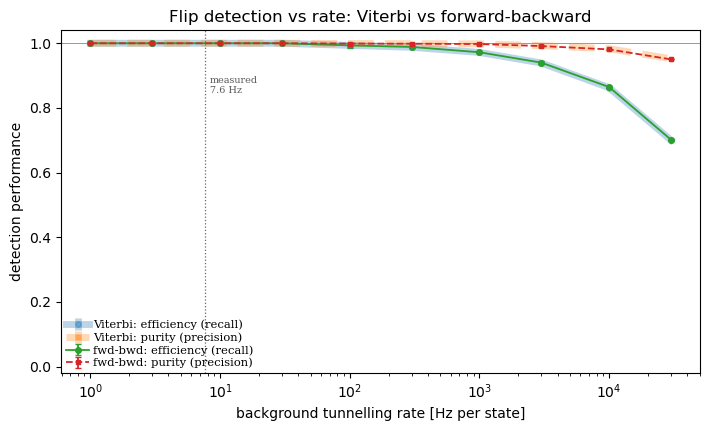

  rate/Hz |    viterbi eff/pur |    fwd-bwd eff/pur
        1 |    1.000    1.000 |    1.000    1.000
        3 |    1.000    1.000 |    1.000    1.000
       10 |    1.000    1.000 |    1.000    1.000
       30 |    1.000    1.000 |    1.000    1.000
      100 |    0.993    0.999 |    0.993    0.999
      300 |    0.988    0.999 |    0.989    0.999
     1000 |    0.972    0.998 |    0.972    0.998
     3000 |    0.939    0.993 |    0.940    0.991
    1e+04 |    0.863    0.983 |    0.865    0.981
    3e+04 |    0.700    0.952 |    0.702    0.950


In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
# Viterbi thick and translucent, forward-backward thin on top: where they agree
# exactly -- which is most of this curve -- the thin line sits inside the band.
plot_efficiency_vs_rate(sweeps["viterbi"], ax=ax, label_prefix="Viterbi: ",
                        lw=5, alpha=0.30, capsize=0)
plot_efficiency_vs_rate(sweeps["posterior"], ax=ax, label_prefix="fwd-bwd: ",
                        decorate=False, lw=1.3)
ax.set_title("Flip detection vs rate: Viterbi vs forward-backward")
plt.show()

print(f"{'rate/Hz':>9} | {'viterbi eff/pur':>18} | {'fwd-bwd eff/pur':>18}")
for r, a, b in zip(RATES, sweeps["viterbi"], sweeps["posterior"]):
    print(f"{r:9.4g} | {a.efficiency[0]:8.3f} {a.purity[0]:8.3f} "
          f"| {b.efficiency[0]:8.3f} {b.purity[0]:8.3f}")

The two curves lie on top of each other. That is not a null result — it is the
useful one: **at this contrast the choice of decoder does not matter.** When the
branches are well separated the posterior is saturated near 0 and 1, so
thresholding it returns exactly the most likely sequence.

They can only differ where the posterior spends time near ½. The next cell
forces that by scaling the replayed noise.

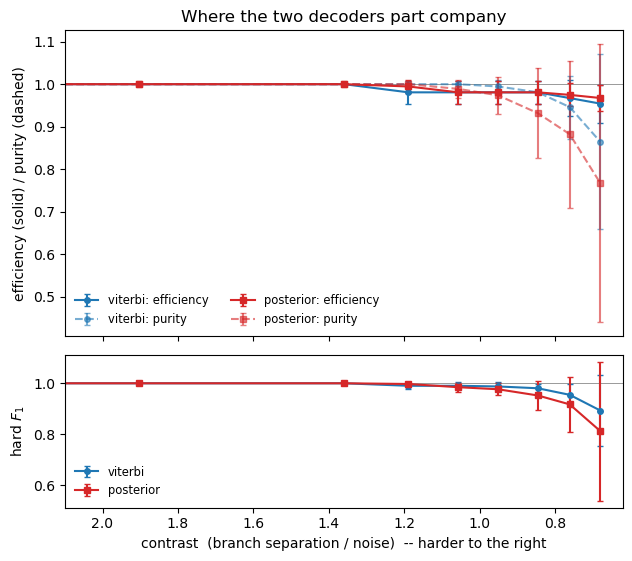

 contrast |       viterbi eff/pur/F1 |       fwd-bwd eff/pur/F1
     3.80 |   1.000   1.000   1.000 |   1.000   1.000   1.000
     1.90 |   1.000   1.000   1.000 |   1.000   1.000   1.000
     1.36 |   1.000   1.000   1.000 |   1.000   1.000   1.000
     1.19 |   0.981   1.000   0.990 |   0.995   1.000   0.997
     1.06 |   0.981   1.000   0.990 |   0.981   0.989   0.985
     0.95 |   0.981   0.995   0.988 |   0.981   0.974   0.977
     0.85 |   0.981   0.981   0.980 |   0.981   0.932   0.952
     0.76 |   0.967   0.946   0.955 |   0.975   0.882   0.917
     0.68 |   0.954   0.864   0.893 |   0.967   0.767   0.812


In [13]:
fids = {d: characterize_trace(iq, SR, decoder=d) for d in DECODERS}
# Sample where the action is: the curves are flat and identical above contrast
# ~1.5, so spend the points below it.
SCALES = [1.0, 2.0, 2.8, 3.2, 3.6, 4.0, 4.5, 5.0, 5.6]
contrast = [fid.contrast_median / s for s in SCALES]
res = {d: [benchmark_reconstruction(fidelity=fids[d], n_trials=8,
                                    noise_scale=s, rate_jitter=False)
           for s in SCALES] for d in DECODERS}

fig, (ax, axf) = plt.subplots(2, 1, figsize=(7.2, 6.2), sharex=True,
                              gridspec_kw={"height_ratios": [2, 1],
                                           "hspace": 0.08})
for d, col, mark in (("viterbi", "C0", "o"), ("posterior", "C3", "s")):
    ax.errorbar(contrast, [r.efficiency[0] for r in res[d]],
                yerr=[r.efficiency[1] for r in res[d]], color=col, marker=mark,
                ls="-", ms=4, capsize=2.5, lw=1.5, label=f"{d}: efficiency")
    ax.errorbar(contrast, [r.purity[0] for r in res[d]],
                yerr=[r.purity[1] for r in res[d]], color=col, marker=mark,
                ls="--", ms=4, capsize=2.5, lw=1.5, alpha=0.6,
                label=f"{d}: purity")
    axf.errorbar(contrast, [r.hard_f1[0] for r in res[d]],
                 yerr=[r.hard_f1[1] for r in res[d]], color=col, marker=mark,
                 ls="-", ms=4, capsize=2.5, lw=1.5, label=d)
for a in (ax, axf):
    a.axhline(1.0, color="0.6", lw=0.7, zorder=0)
# The axes share x, so invert once -- inverting both flips it back.
ax.set_xlim(2.1, 0.62)     # decreasing: harder to the right. Flat and
                           # identical above ~1.4, so the rest is cropped.
ax.set_ylabel("efficiency (solid) / purity (dashed)")
ax.set_title("Where the two decoders part company")
ax.legend(loc="lower left", frameon=False, fontsize="small", ncol=2)
axf.set_xlabel("contrast  (branch separation / noise)  -- harder to the right")
axf.set_ylabel("hard $F_1$")
axf.legend(frameon=False, fontsize="small")
plt.show()

print(f"{'contrast':>9} | {'viterbi eff/pur/F1':>24} | {'fwd-bwd eff/pur/F1':>24}")
for c, a, b in zip(contrast, res["viterbi"], res["posterior"]):
    print(f"{c:9.2f} | {a.efficiency[0]:7.3f} {a.purity[0]:7.3f} {a.hard_f1[0]:7.3f} "
          f"| {b.efficiency[0]:7.3f} {b.purity[0]:7.3f} {b.hard_f1[0]:7.3f}")

There it is, and it is the textbook trade. As the contrast falls the posterior
rule buys **recall at the cost of purity**: it follows brief excursions,
recovering real flips Viterbi smooths over while also promoting noise into
flips.

Two things worth reading carefully rather than sloganising:

- Just above contrast ≈ 1 the extra recall is close to *free* — purity has
  barely moved, so forward-backward can edge ahead on $F_1$ there.
- Below that, purity falls away much faster than recall rises, and the sequence
  prior wins clearly on $F_1$. That is why Viterbi is the default.

So the honest summary is not "Viterbi is better". It is that the two agree
wherever the measurement is comfortable, and where they differ the right choice
depends on what a mistake costs you: if a missed event is worse than a spurious
one — a burst search, say — forward-backward is the better trade, and this is
the plot that says by how much.

## 7. Burst diagnostics under both decoders

`detect_bursts` clusters the reconstructed flip train against the Poisson
background with a trials-corrected scan statistic. Two questions: how big must a
burst be before it is found, and once found how many of its quasiparticles are
counted?

The background rate comes from the **data** — the de-biased `corrected_rate_hz`,
not an assumption. Too low a value manufactures bursts out of background pairs,
too high dissolves the small ones.

background rate from the data: 7.60 Hz per state


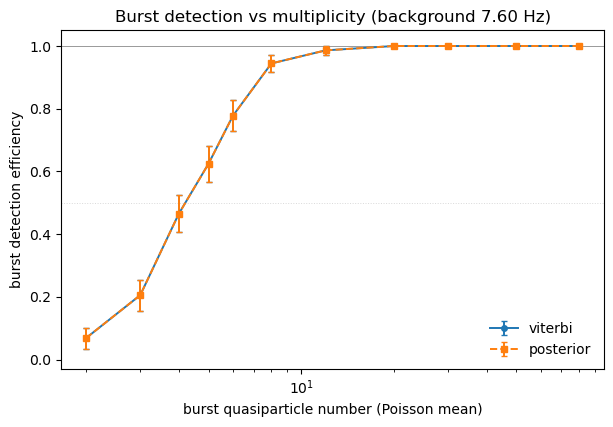

In [14]:
N_QP = [2, 3, 4, 5, 6, 8, 12, 20, 30, 50, 80]
bg = report.corrected_rate_hz
pts = {d: sweep_burst_size(fids[d], N_QP, background_rate_hz=bg, n_trials=4)
       for d in DECODERS}
print(f"background rate from the data: {bg:.2f} Hz per state")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
for d, mark, ls in (("viterbi", "o", "-"), ("posterior", "s", "--")):
    ax.errorbar([p.n_qp_expected for p in pts[d]],
                [p.efficiency for p in pts[d]],
                yerr=[p.efficiency_err for p in pts[d]],
                marker=mark, ls=ls, ms=4, capsize=2.5, lw=1.4, label=d)
ax.axhline(1.0, color="0.6", lw=0.7, zorder=0)
ax.axhline(0.5, color="0.85", lw=0.7, ls=":", zorder=0)
ax.set_xscale("log")
ax.set_xlabel("burst quasiparticle number (Poisson mean)")
ax.set_ylabel("burst detection efficiency")
ax.set_ylim(-0.03, 1.05)
ax.set_title(f"Burst detection vs multiplicity (background {bg:.2f} Hz)")
ax.legend(frameon=False)
plt.show()

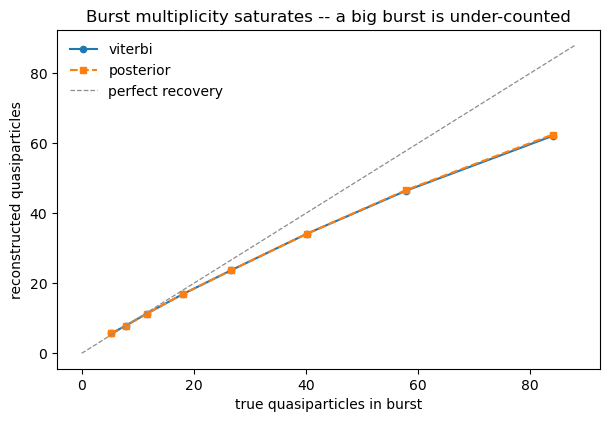

 n_qp |    viterbi <det>  bias |    fwd-bwd <det>  bias
    2 |        5.5      +0.8 |        5.5      +0.8
    3 |        5.9      +0.6 |        5.9      +0.6
    4 |        6.2      +0.3 |        6.2      +0.3
    5 |        6.9      +0.2 |        6.9      +0.2
    6 |        7.0      +0.0 |        7.0      +0.0
    8 |        8.2      -0.0 |        8.2      -0.0
   12 |       12.0      -0.4 |       12.0      -0.4
   20 |       18.6      -1.5 |       18.7      -1.5
   30 |       25.8      -3.6 |       25.8      -3.6
   50 |       41.8      -8.7 |       41.8      -8.6
   80 |       59.6     -20.4 |       60.0     -20.0


In [15]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
for d, mark, ls in (("viterbi", "o", "-"), ("posterior", "s", "--")):
    t = np.concatenate([p.n_qp_true for p in pts[d] if p.n_qp_true.size])
    r = np.concatenate([p.n_qp_detected for p in pts[d] if p.n_qp_detected.size])
    edges = np.unique(np.round(np.geomspace(max(t.min(), 1), t.max(), 10)))
    idx = np.clip(np.digitize(t, edges) - 1, 0, edges.size - 2)
    bx = [t[idx == b].mean() for b in range(edges.size - 1) if (idx == b).sum() >= 3]
    by = [r[idx == b].mean() for b in range(edges.size - 1) if (idx == b).sum() >= 3]
    ax.plot(bx, by, marker=mark, ls=ls, ms=4.5, lw=1.5, label=d)
hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, hi], [0, hi], color="0.55", lw=0.9, ls="--", label="perfect recovery")
ax.set_xlabel("true quasiparticles in burst")
ax.set_ylabel("reconstructed quasiparticles")
ax.set_title("Burst multiplicity saturates -- a big burst is under-counted")
ax.legend(frameon=False)
plt.show()

print(f"{'n_qp':>5} | {'viterbi <det>  bias':>22} | {'fwd-bwd <det>  bias':>22}")
for a, b in zip(pts["viterbi"], pts["posterior"]):
    print(f"{a.n_qp_expected:5.0f} | {a.mean_n_qp_detected:10.1f} {a.bias:+9.1f} "
          f"| {b.mean_n_qp_detected:10.1f} {b.bias:+9.1f}")

The burst curves for the two decoders lie on top of each other, for the same
reason the rate curves did: at this contrast the posterior is saturated, so the
two decoding rules return the same sequence. The decoder is not a knob worth
turning at a comfortable operating point — it only becomes one near the noise
floor.

## 8. What to take away

- **The benchmark predicts.** Efficiency and purity measured on surrogates
  match what the reconstruction actually achieved on the trace whose truth we
  withheld (§3).
- **Read `report.warnings` before quoting anything.** On a degenerate trace the
  fitted model is spurious, so the surrogates replay a *fiction* that
  reconstructs well.
- **Crowding costs recall, not precision.** Lost flips vanish silently rather
  than being replaced by spurious ones, so a falling recall with intact purity
  means crowding, while purity falling too means the decoder is segmenting
  noise.
- **Burst multiplicity saturates.** Above ~20 quasiparticles a quoted count is
  a lower bound, not a measurement — a property of parity readout, not of the
  clustering.
- **The decoder choice is irrelevant at good contrast** and becomes a
  recall-vs-purity trade below contrast ≈ 1. Viterbi wins on F1, which is why
  it is the default; forward-backward is the better choice if a miss costs you
  more than a false positive.